<a href="https://colab.research.google.com/github/OswaldVc/AnaDat/blob/main/S5_Anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

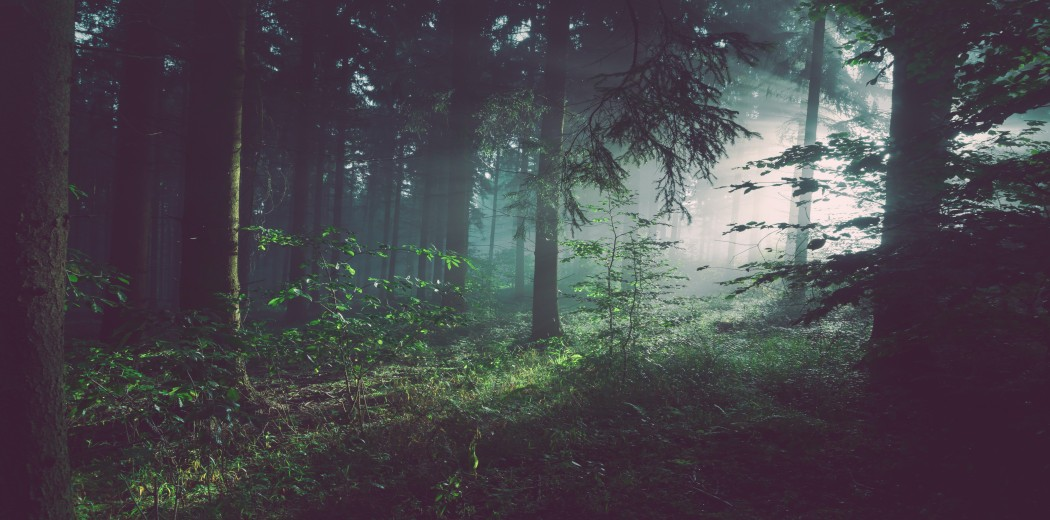



# __Análisis de datos - Detección de anomalías__
>> ## **By Néstor O. Vásquez C.**

# __Introducción a Análisis de Datos - Detección de Anomalías__

<P align="justify">
En un mundo donde los datos fluyen sin descanso, identificar lo que se sale de lo común es clave para la toma de decisiones inteligentes. La detección de anomalías es una de las herramientas más poderosas en el análisis de datos, ya que nos permite encontrar patrones inesperados, posibles fallas y hasta fraudes antes de que se conviertan en problemas mayores.<P/>

<P align="justify">
Desde la identificación de transacciones sospechosas en sistemas bancarios hasta el monitoreo de sensores en la industria, el análisis de anomalías es una pieza clave para optimizar procesos, mejorar la seguridad y prevenir pérdidas. Pero, ¿cómo sabemos qué es realmente una anomalía? ¿Cómo diferenciamos un comportamiento inusual de una simple variabilidad natural? <P/>

<P align="justify">
En este recorrido, exploraremos los métodos más utilizados para la detección de anomalías, desde técnicas tradicionales hasta algoritmos avanzados de aprendizaje automático, entendiendo cómo cada enfoque se adapta a distintos escenarios. Más que números, se trata de transformar los datos en conocimiento útil para anticiparnos a lo inesperado.<P/>

**Librerias**

In [2]:
%%capture
!pip install pyod

In [3]:
## Importamos las librerias necesarias en el proyecto:
# Tratamiento de datos
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
import math

# Preprocesado y modelado
# ==============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
from pyod.utils.data import generate_data, get_outliers_inliers

# Gráficas
# ==============================================================================
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

**Conexión con Drive**

In [5]:
%load_ext autoreload
%autoreload 2
from google.colab import drive
drive.mount('/content/drive')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Mounted at /content/drive


**Generación de DF**

In [6]:
# Definir el número de transacciones
num_transactions = 80000

# Generar datos aleatorios para las transacciones
np.random.seed(123)
amounts = np.random.uniform(1, 12000, num_transactions)
dates = [datetime.now() - timedelta(days=random.randint(1, 365)) for _ in range(num_transactions)]
fraudulent = np.random.choice([0, 1], num_transactions, p=[0.99, 0.01])

# Crear un DataFrame para almacenar los datos de las transacciones
data = pd.DataFrame({
    'Date': dates,
    'Amount': amounts,
    'Class': fraudulent
})

# Guardar los datos en un archivo CSV
data.to_csv('/content/sample_data/datos_transacciones_ejercicio.csv', index=False)

print("Archivo 'datos_transacciones.csv' creado exitosamente.")

Archivo 'datos_transacciones.csv' creado exitosamente.


In [7]:
data.head(3)

,Date,Amount,Class
0,2024-06-12 21:37:48.012711,8357.933758,0
1,2025-01-29 21:37:48.012807,3434.385880,0
2,2024-10-30 21:37:48.012814,2722.990591,0


Número total de muestras: 80000
Número de anomalías detectadas: 16305
Porcentaje de anomalías: 20.38%


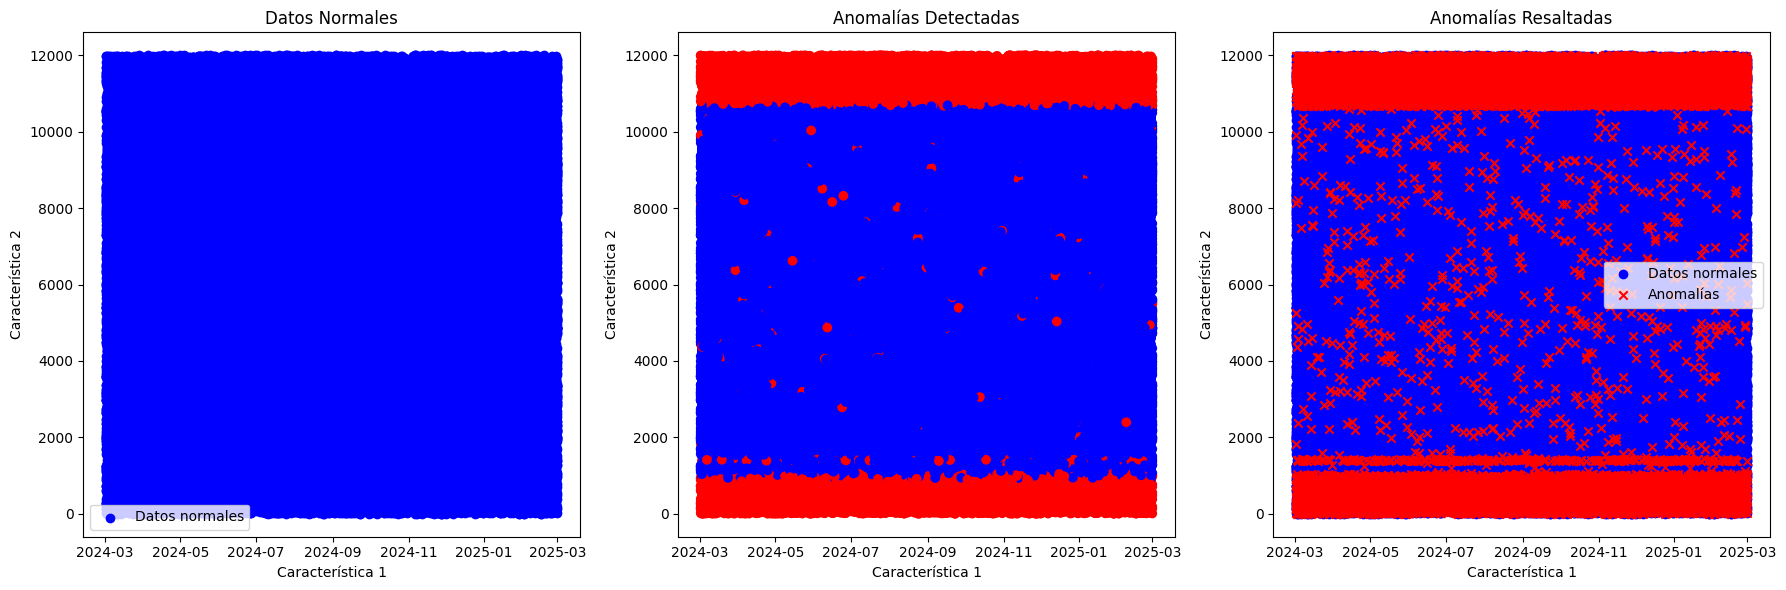

In [8]:
# Seleccionar solo las características numéricas para el escalado
numeric_features = data.select_dtypes(include=[np.number])

# Escalar los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_features)

# Entrenar el modelo de Isolation Forest
isolation_forest = IsolationForest(random_state=0)
isolation_forest.fit(data_scaled)

# Detectar anomalías
anomaly_labels = isolation_forest.predict(data_scaled)

# Contar anomalías
num_anomalies = np.sum(anomaly_labels == -1)
num_transactions = len(data)

# Mostrar resultados por pantalla
anomaly_percentage = (num_anomalies / num_transactions) * 100
print(f"Número total de muestras: {num_transactions}")
print(f"Número de anomalías detectadas: {num_anomalies}")
print(f"Porcentaje de anomalías: {anomaly_percentage:.2f}%")

# Visualizar datos y anomalías
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Visualización de datos normales
axes[0].scatter(data.iloc[:, 0], data.iloc[:, 1], c='b', marker='o', label='Datos normales')
axes[0].set_title('Datos Normales')
axes[0].set_xlabel('Característica 1')
axes[0].set_ylabel('Característica 2')
axes[0].legend()

# Gráfico 2: Visualización de anomalías detectadas
axes[1].scatter(data.iloc[:, 0], data.iloc[:, 1], c=np.where(anomaly_labels == -1, 'r', 'b'), marker='o')
axes[1].set_title('Anomalías Detectadas')
axes[1].set_xlabel('Característica 1')
axes[1].set_ylabel('Característica 2')

# Gráfico 3: Visualización de anomalías resaltadas
axes[2].scatter(data.iloc[:, 0], data.iloc[:, 1], c='b', marker='o', label='Datos normales')
axes[2].scatter(data[anomaly_labels == -1].iloc[:, 0], data[anomaly_labels == -1].iloc[:, 1], c='r', marker='x', label='Anomalías')
axes[2].set_title('Anomalías Resaltadas')
axes[2].set_xlabel('Característica 1')
axes[2].set_ylabel('Característica 2')
axes[2].legend()

plt.tight_layout()
plt.show()